In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



Saving train.csv to train.csv
Missing Values Before Handling:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


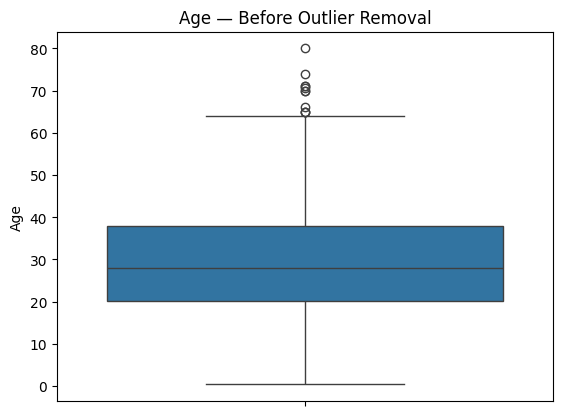

In [2]:
# ── VISUALISE BEFORE CLEANING ──────────
from google.colab import files
uploaded = files.upload()
df = pd.read_csv("train.csv")
print("Missing Values Before Handling:")
print(df.isnull().sum())

sns.boxplot(y=df['Age'])
plt.title('Age — Before Outlier Removal')
plt.show()


In [3]:
# ── COMPUTE IQR ────────────────────────
Q1 = df['Age'].quantile(0.25)
Q3 = df['Age'].quantile(0.75)
IQR = Q3 - Q1


In [6]:
# ── DEFINE BOUNDS ──────────────────────
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Lower: {lower_bound:.2f}, Upper: {upper_bound:.2f}")

Lower: -6.69, Upper: 64.81


In [7]:
# ── DETECT OUTLIERS ────────────────────
outliers = df[(df['Age'] < lower_bound) |
              (df['Age'] > upper_bound)]
print(f"Outliers found: {len(outliers)}")


Outliers found: 11


In [8]:
# ── REMOVE OUTLIERS ────────────────────
df_clean = df[(df['Age'] >= lower_bound) &
              (df['Age'] <= upper_bound)]
print(f"Rows after removal: {len(df_clean)}")


Rows after removal: 703


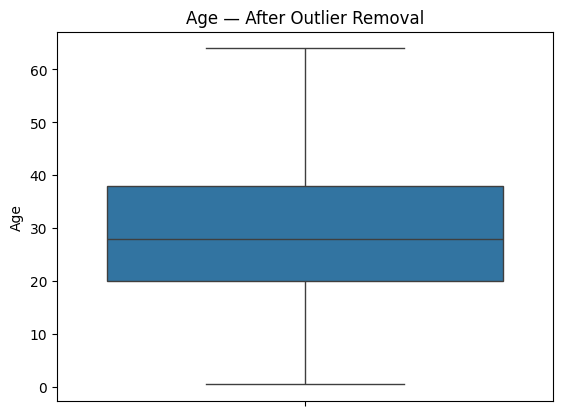

In [9]:
# ── VISUALISE AFTER CLEANING ───────────
sns.boxplot(y=df_clean['Age'])
plt.title('Age — After Outlier Removal')
plt.show()
